# **Importación del dataset ECG**

In [1]:
#Importación de librerías
import matplotlib.pyplot as plt
import numpy as np
import pickle

with open('dataset_ECG.pkl', 'rb') as f:
    ecg = pickle.load(f)

## Descripción de categoria de los ejercicios realizado en la clase de ECG

| Descripción | Categoría |
|----------|----------|
|Basal 1                    |0|
|Inhalación y exhalación    |1|
|Basal 2                    |2|
|Reposo 1                   |3|
|Reposo 2                   |4|

* **Basal 1:** Primera medición en reposo basal.
* **Inhalación y exhalación:** Ciclo de repeticiones de inhalación y exhalación, con un aguante de 5 segundos por proceso.
* **Basal 2:** Segunda medición en reposo basal.
* **Reposo 1:** Medición del reposo inmediatamente después del ejercicio de alta exigencia.
* **Reposo 2:** Medición del reposo 3 mintos después del ejercicio de alta exigencia.

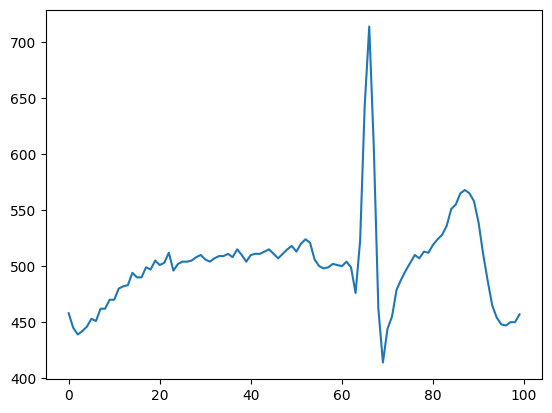

In [2]:
plt.plot(ecg['base'][0])

# **Filtrado de las señales**

## **Creación de filtros**

In [3]:
from scipy.signal import firwin, lfilter
from tqdm import tqdm

def fftplot(signal,Fs):
    N = 2**10                                     # 10 bits, 0-1023

    signal_fft = np.fft.fft(signal, N)           # fft magtinud
    signal_fft = np.round(np.abs(signal_fft),3)[0:N//2] # nos quedamos con los componente de la derecha de la FFT
    signal_aux = signal_fft/signal_fft.max()     # hallamos el maximo para pasar la magnitud a escala db

    with np.errstate(divide='ignore'):
        signal_fft_db = 10*np.log10(signal_aux)  # , out=signal_aux, where=signal_aux >= 0 para evitar division por zero

    F_list = np.linspace(0,Fs/2, N//2)
    F = np.round(F_list[np.argmax(signal_fft_db)], 1)   # argmax, encuentra el argumento max en un array

    plt.figure()
    plt.plot(F_list, signal_fft_db)  #10 * np.log10(P / Pref) , decibelios
    plt.text(F,0, f"{F}Hz")
    plt.grid(linestyle=":")
    plt.ylabel("Magnitud (db)")
    plt.xlabel("Frecuencias (Hz)")
    plt.title("FFT en decibelios")
    plt.xlim([0,50])
    plt.xticks(np.arange(0,50,10))
    plt.show()



## Basal

### Señal cruda

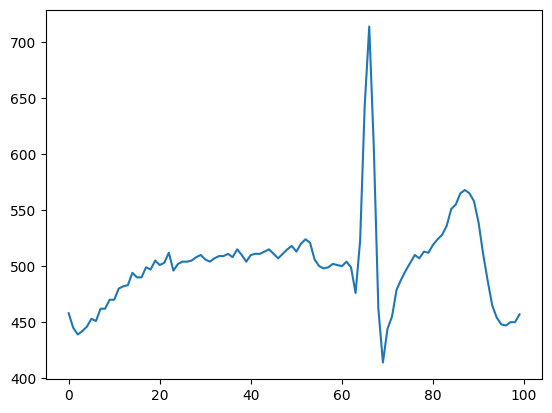

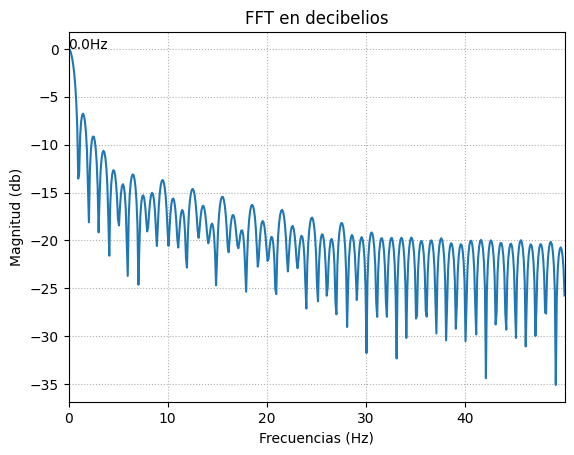

In [4]:
i=np.where(ecg['target'] == 0)[0][0]
plt.plot(ecg['base'][i])
# plt.title('Señal cruda')
fftplot(ecg['base'][i],100)

### Aplicación del filtro IIR

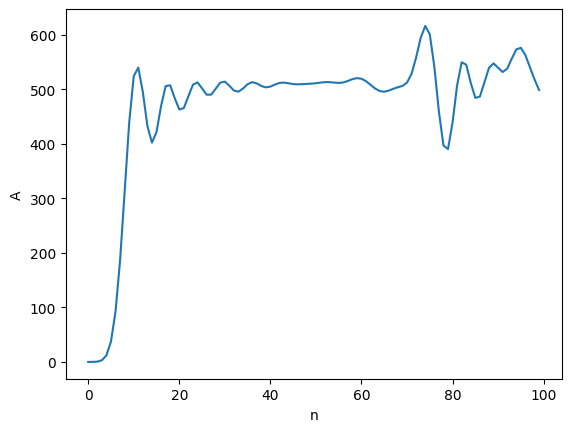

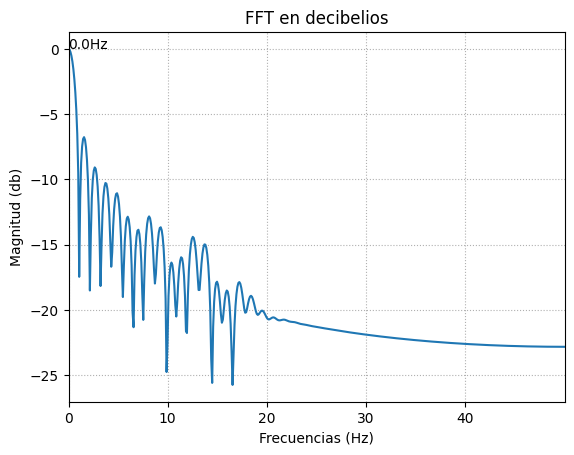

In [5]:
# filtro butterworth

b= [7.089056609992896e-06,9.215773592990765e-05,0.0005529464155794459,0.002027470190457968,0.00506867547614492,0.009123615857060858,0.01216482114274781,0.01216482114274781,0.009123615857060858,0.005068675476144921,0.0020274701904579684,0.0005529464155794459,9.215773592990765e-05,7.089056609992896e-06]
a=[1.0,-4.396913622684017,10.288830418376556,-15.977000405288257,18.049561596736098,-15.459412190548305,10.245969825991795,-5.287369082137747,2.1148442217702623,-0.6451543612877249,0.14547208450262253,-0.0229024526238563,0.002251751690510084,-0.0001042327488737384]
y = lfilter(b, a,ecg['base'][i])

plt.plot(y)
# plt.title('Señal filtrada con filtro IIR')
plt.xlabel('n')
plt.ylabel('A')
fftplot(y,100)

### Aplicación del filtro FIR

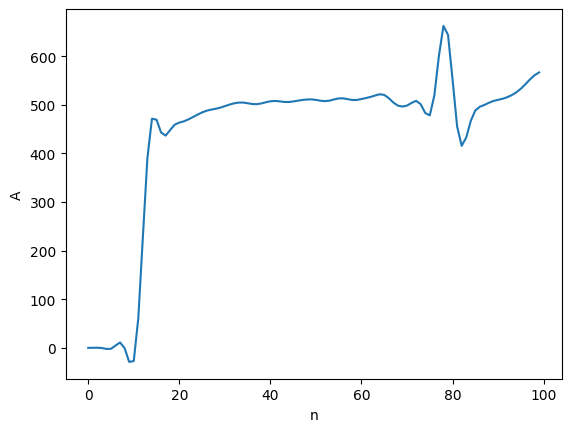

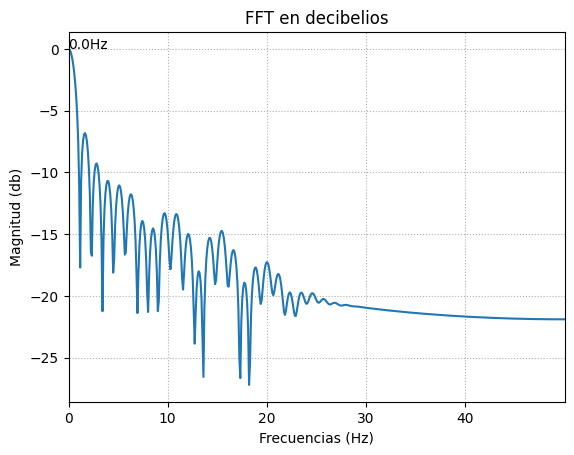

In [6]:
# filtro blackman

b= [-2.773308729178978e-20,0.00015624677013807662,0.00039952543561280084,-0.0012883375915101335,-0.004125474755076778,0.0004014790972649038,0.014584553135806288,0.014227806964881134,-0.025130857055955507,-0.0621490627984695,0.0016987597149737972,0.19097426419806832,0.3702510968842667,0.37025109688426666,0.19097426419806826,0.0016987597149737972,-0.06214906279846946,-0.02513085705595549,0.014227806964881125,0.01458455313580627,0.0004014790972649038,-0.004125474755076772,-0.0012883375915101294,0.00039952543561280084,0.00015624677013807627,-2.773308729178978e-20]
y = lfilter(b, np.array(1),ecg['base'][i])

plt.plot(y)
# plt.title('Señal filtrada con filtro FIR')
plt.xlabel('n')
plt.ylabel('A')
fftplot(y,100)

## Respiración

### Señal cruda

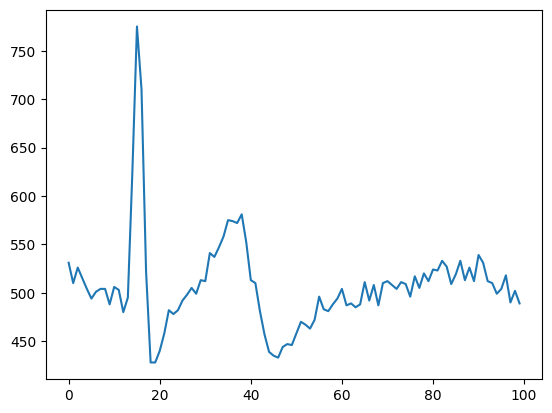

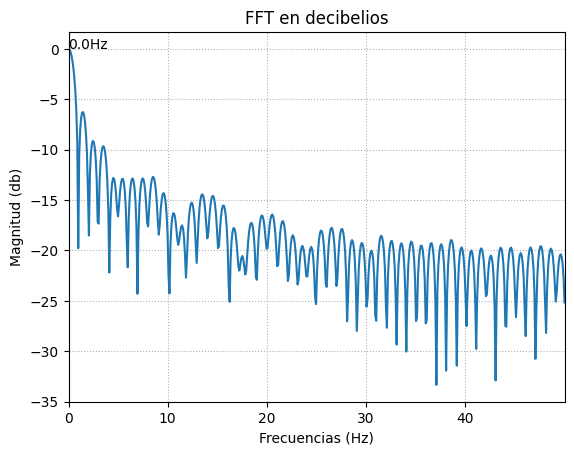

In [7]:
i=np.where(ecg['target'] == 1)[0][0]
plt.plot(ecg['base'][i])
# plt.title('Señal cruda')
fftplot(ecg['base'][i],100)

### Aplicación del filtro IIR

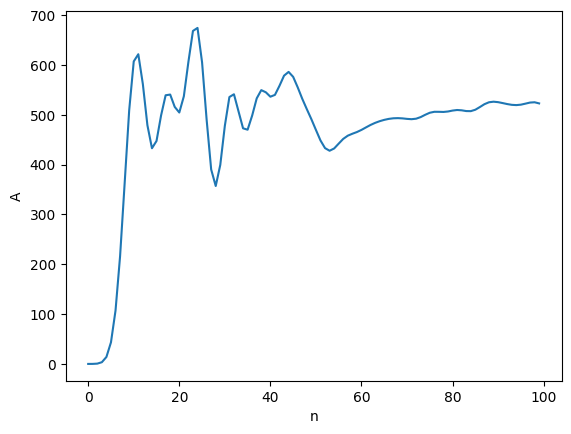

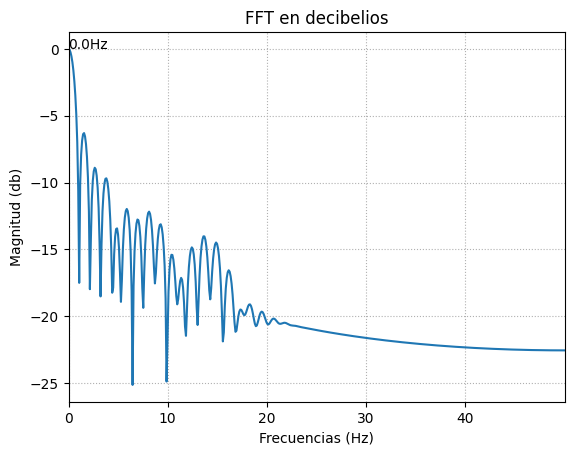

In [8]:
# filtro butterworth

b= [7.089056609992896e-06,9.215773592990765e-05,0.0005529464155794459,0.002027470190457968,0.00506867547614492,0.009123615857060858,0.01216482114274781,0.01216482114274781,0.009123615857060858,0.005068675476144921,0.0020274701904579684,0.0005529464155794459,9.215773592990765e-05,7.089056609992896e-06]
a=[1.0,-4.396913622684017,10.288830418376556,-15.977000405288257,18.049561596736098,-15.459412190548305,10.245969825991795,-5.287369082137747,2.1148442217702623,-0.6451543612877249,0.14547208450262253,-0.0229024526238563,0.002251751690510084,-0.0001042327488737384]
y = lfilter(b, a,ecg['base'][i])

plt.plot(y)
# plt.title('Señal filtrada con filtro IIR')
plt.xlabel('n')
plt.ylabel('A')
fftplot(y,100)

### Aplicación del filtro FIR

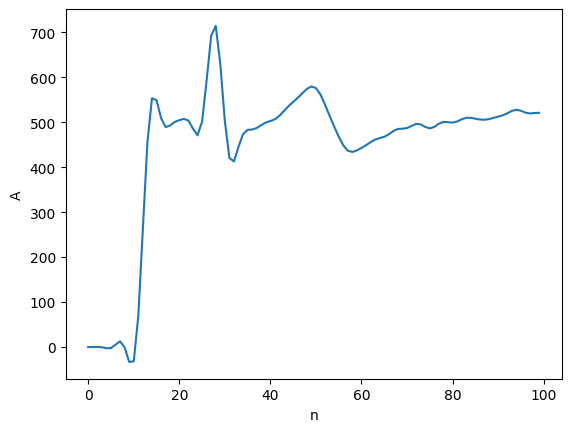

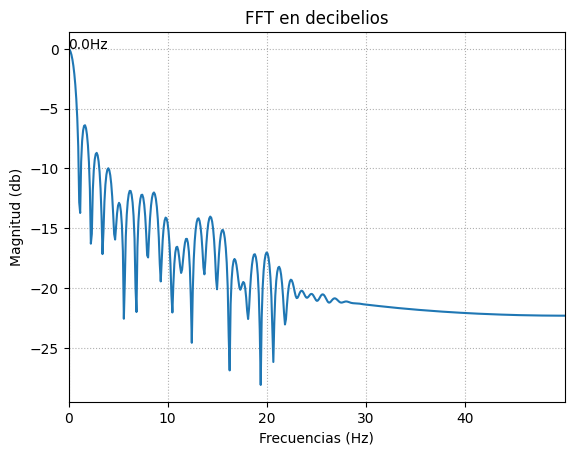

In [9]:
# filtro blackman

b= [-2.773308729178978e-20,0.00015624677013807662,0.00039952543561280084,-0.0012883375915101335,-0.004125474755076778,0.0004014790972649038,0.014584553135806288,0.014227806964881134,-0.025130857055955507,-0.0621490627984695,0.0016987597149737972,0.19097426419806832,0.3702510968842667,0.37025109688426666,0.19097426419806826,0.0016987597149737972,-0.06214906279846946,-0.02513085705595549,0.014227806964881125,0.01458455313580627,0.0004014790972649038,-0.004125474755076772,-0.0012883375915101294,0.00039952543561280084,0.00015624677013807627,-2.773308729178978e-20]
y = lfilter(b, np.array(1),ecg['base'][i])

plt.plot(y)
# plt.title('Señal filtrada con filtro FIR')
plt.xlabel('n')
plt.ylabel('A')
fftplot(y,100)

## Post-Ejercicio

### Señal cruda

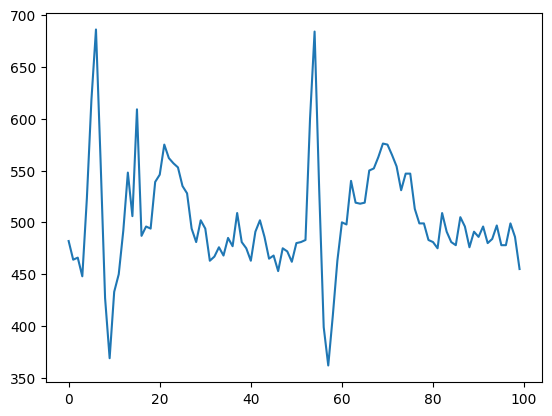

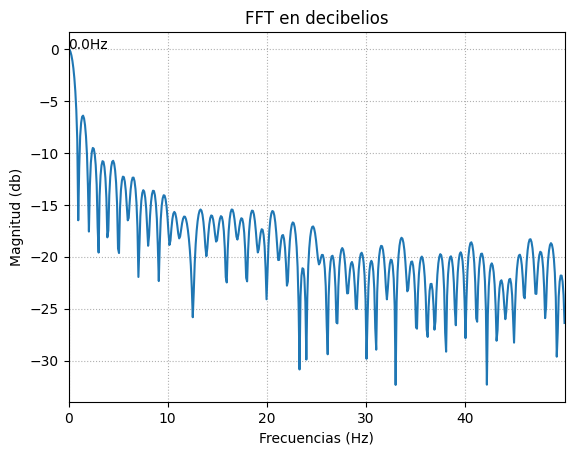

In [10]:
i=np.where(ecg['target'] == 3)[0][0]
plt.plot(ecg['base'][i])
# plt.title('Señal cruda')
fftplot(ecg['base'][i],100)

### Aplicación del filtro IIR

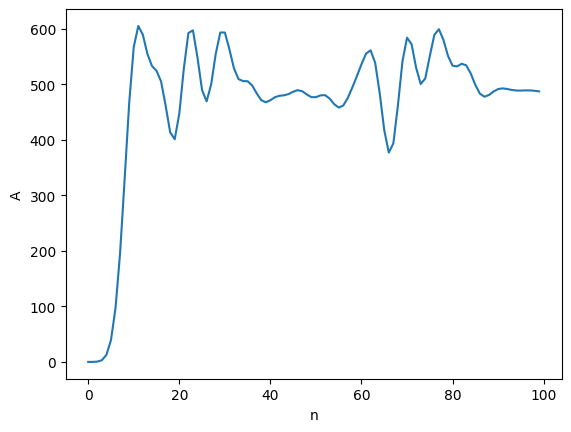

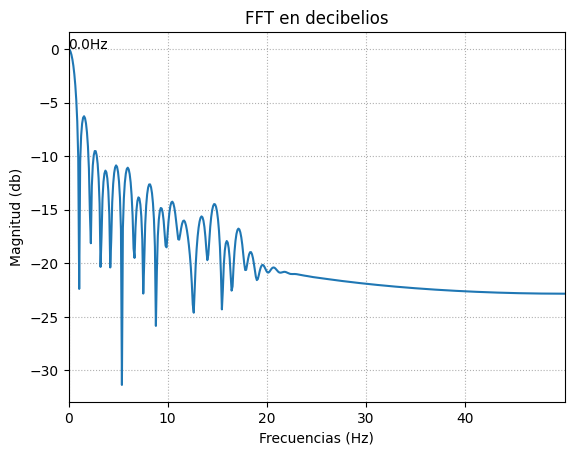

In [11]:
# filtro butterworth

b= [7.089056609992896e-06,9.215773592990765e-05,0.0005529464155794459,0.002027470190457968,0.00506867547614492,0.009123615857060858,0.01216482114274781,0.01216482114274781,0.009123615857060858,0.005068675476144921,0.0020274701904579684,0.0005529464155794459,9.215773592990765e-05,7.089056609992896e-06]
a=[1.0,-4.396913622684017,10.288830418376556,-15.977000405288257,18.049561596736098,-15.459412190548305,10.245969825991795,-5.287369082137747,2.1148442217702623,-0.6451543612877249,0.14547208450262253,-0.0229024526238563,0.002251751690510084,-0.0001042327488737384]
y = lfilter(b, a,ecg['base'][i])

plt.plot(y)
# plt.title('Señal filtrada con filtro IIR')
plt.xlabel('n')
plt.ylabel('A')
fftplot(y,100)

### Aplicación del filtro FIR

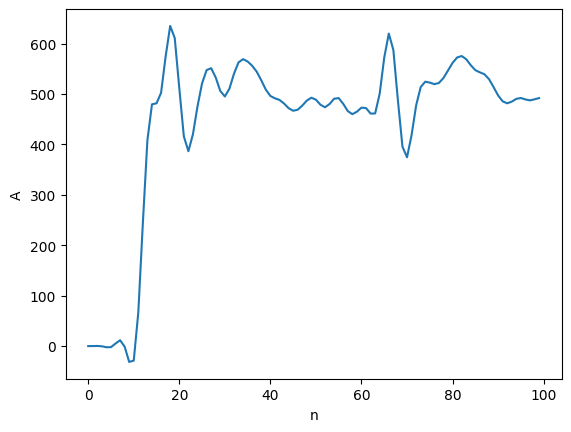

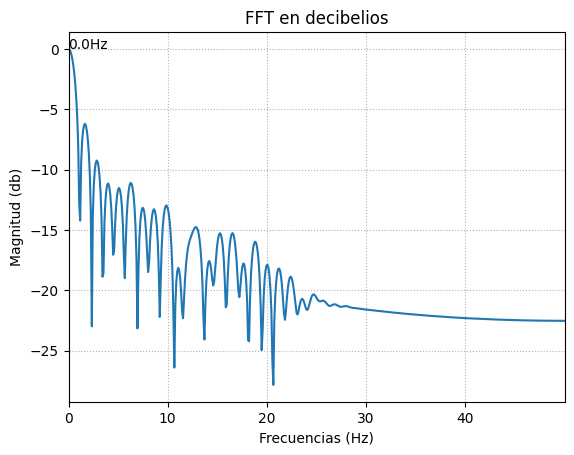

In [12]:
# filtro blackman

b= [-2.773308729178978e-20,0.00015624677013807662,0.00039952543561280084,-0.0012883375915101335,-0.004125474755076778,0.0004014790972649038,0.014584553135806288,0.014227806964881134,-0.025130857055955507,-0.0621490627984695,0.0016987597149737972,0.19097426419806832,0.3702510968842667,0.37025109688426666,0.19097426419806826,0.0016987597149737972,-0.06214906279846946,-0.02513085705595549,0.014227806964881125,0.01458455313580627,0.0004014790972649038,-0.004125474755076772,-0.0012883375915101294,0.00039952543561280084,0.00015624677013807627,-2.773308729178978e-20]
y = lfilter(b, np.array(1),ecg['base'][i])

plt.plot(y)
# plt.title('Señal filtrada con filtro FIR')
plt.xlabel('n')
plt.ylabel('A')
fftplot(y,100)